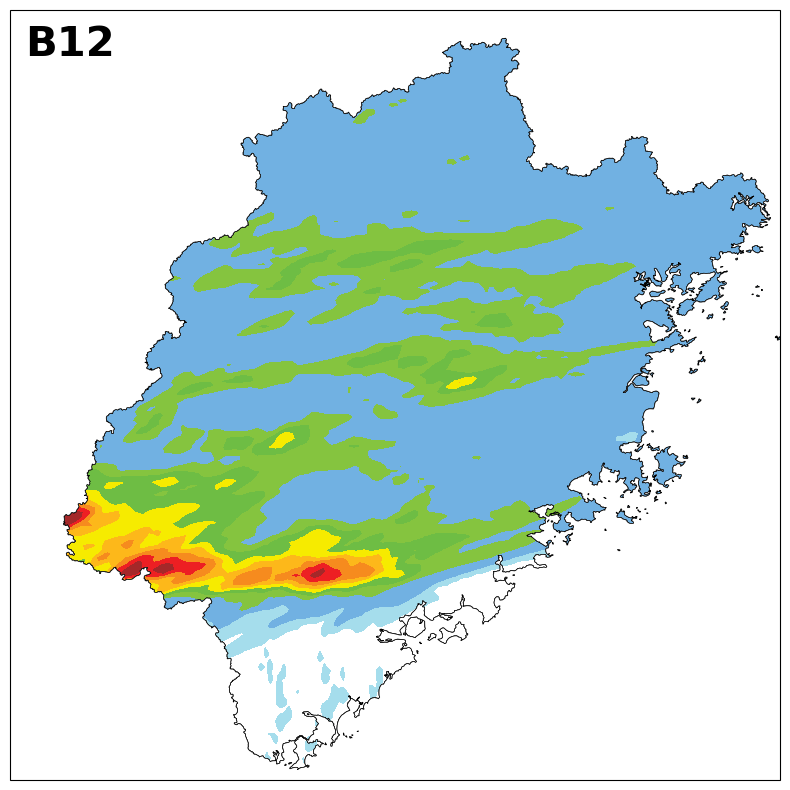

In [5]:
import numpy as np
from netCDF4 import Dataset
from wrf import (getvar, to_np) 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.io.shapereader import BasicReader
import matplotlib.ticker as mticker
import geopandas as gpd
import rioxarray
import xarray as xr
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
f=(
"E:/000_FuJian/wrfout_FuJian/d02/a1_d02.nc")
ncfile = Dataset(f)
R_last = to_np(getvar(ncfile, "RAINC", timeidx=-1)) + to_np(getvar(ncfile, "RAINNC", timeidx=-1)) + to_np(getvar(ncfile, "RAINSH", timeidx=-1))
lon = np.array(ncfile['XLONG'])[0,:,:]
lat = np.array(ncfile['XLAT'])[0,:,:]
R = R_last

# shape文件读取
#countries = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
#ten       = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
#province  = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
countries = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan.shp")
ten       = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan.shp")
province  = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan.shp")
#countries = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan_lbt.shp")
#ten       = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan_lbt.shp")
#province  = BasicReader(r"C:/Users/xmxm/Desktop/slt/fj_qufan_lbt.shp")

# 颜色条设置
rgb= ([255, 255, 255], [165, 221, 236], [113, 177, 226], [133, 196, 63],
      [110, 189, 68], [246, 235, 0], [253, 184, 26], [246, 139, 30], 
      [237, 31, 35], [164, 40, 41], [167, 68, 152], [200, 100, 200]
    )
clors = np.array(rgb)/255.
clevs = [0.1, 1, 10, 50, 75, 100, 125, 150, 175, 200, 250, 300,400]

#rgb=([237,237,237],[209,209,209],[173,173,173],[131,131,131],
#[93,93,93],[151,198,223],[111,176,214],[49,129,189],
#[26,104,174],[8,79,153],[62,168,91],[110,193,115],
#[154,214,149],[192,230,185],[223,242,217],[255,255,164],
##[255,243,0],[255,183,0],[255,123,0],[255,62,0],
#[255,2,0],[196,0,0],[136,0,0],
#    )
#clors = np.array(rgb)/255.
#clevs = [0.1, 1, 10, 50, 100, 125, 150, 175, 200, 250 ]

# 画图
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
contour = ax.contourf(lon,lat, R, clevs, colors=clors, transform=ccrs.PlateCarree())
###图例
#cb_cf = fig.colorbar(contour, ax=ax,ticks=clevs, shrink=.65)

#g1=ax.gridlines(draw_labels=True,linewidth=3,color='none',alpha=0.5,linestyle='--',x_inline=False,y_inline=False)
g1.top_labels=False
g1.right_labels=False

g1.xformatter=LONGITUDE_FORMATTER
g1.yformatter=LATITUDE_FORMATTER
g1.rotate_labels=False
g1.xlocator = mticker.FixedLocator(np.arange(60,140,1))
g1.ylocator = mticker.FixedLocator(np.arange(10,60,1))
g1.xlabel_style={'size':17}
g1.ylabel_style={'size':17}
#plt.title('B12', fontsize=20, fontweight='bold')

plt.text(0.02, 0.98, 'B12', fontsize=30, fontweight='bold', ha='left', va='top', transform=ax.transAxes)

ax.add_geometries(countries.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='white') 
ax.add_geometries(ten.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='white') 
ax.add_geometries(province.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='white') 
ax.set_extent([115.5,120.5,23.5,28.5],crs=ccrs.PlateCarree()) # 小范围D03准确福建
#fujian=BasicReader(r"C:/Users/xmxm/Desktop/slt/fujian.shp", encoding='gbk')
#ax.add_geometries(fujian.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='none')
#ax.set_extent([60,140,10,60],crs=ccrs.PlateCarree()) # 全国


In [7]:
import os
import re
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, to_np 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io.shapereader import BasicReader
from PIL import Image

def plot_precipitation(f, shapefile, output_dir):
    ncfile = Dataset(f)
    R_last = to_np(getvar(ncfile, "RAINC", timeidx=-1)) + to_np(getvar(ncfile, "RAINNC", timeidx=-1)) + to_np(getvar(ncfile, "RAINSH", timeidx=-1))
    lon = np.array(ncfile['XLONG'])[0,:,:]
    lat = np.array(ncfile['XLAT'])[0,:,:]
    R = R_last

    countries = BasicReader(shapefile)
    ten = BasicReader(shapefile)
    province = BasicReader(shapefile)

    rgb = ([255, 255, 255], [165, 221, 236], [113, 177, 226], [133, 196, 63],
           [110, 189, 68], [246, 235, 0], [253, 184, 26], [246, 139, 30], 
           [237, 31, 35], [164, 40, 41], [167, 68, 152], [200, 100, 200])
    clors = np.array(rgb) / 255.
    clevs = [0.1, 1, 10, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400]

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    contour = ax.contourf(lon, lat, R, clevs, colors=clors, transform=ccrs.PlateCarree())

    # Extract the title from the file name
    title = os.path.splitext(os.path.basename(f))[0].split('_')[0].upper()

    # Place title inside the plot
    plt.text(0.02, 0.98, title, fontsize=30, fontweight='bold', ha='left', va='top', transform=ax.transAxes)

    # Remove gridline labels and gridlines
    ax.gridlines(draw_labels=False, linewidth=0)

    ax.add_geometries(countries.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.add_geometries(ten.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.add_geometries(province.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.set_extent([115.5, 120.5, 23.5, 28.5], crs=ccrs.PlateCarree())

    output_file = os.path.join(output_dir, f"{title}.png")
    plt.savefig(output_file, dpi=600)
    plt.close()

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]

def resize_image(img, max_pixels=178956970):
    width, height = img.size
    current_pixels = width * height
    if current_pixels > max_pixels:
        scale = np.sqrt(max_pixels / current_pixels)
        new_width = int(width * scale)
        new_height = int(height * scale)
        img = img.resize((new_width, new_height), Image.ANTIALIAS)
    return img

def combine_images(image_dir, output_image_path, images_per_row=4):
    image_files = [os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith(".png")]
    image_files.sort(key=natural_sort_key)

    images = [Image.open(file) for file in image_files]

    # Resize each image if necessary
    resized_images = [resize_image(img) for img in images]

    widths, heights = zip(*(img.size for img in resized_images))

    max_width = max(widths)
    max_height = max(heights)

    rows = (len(resized_images) + images_per_row - 1) // images_per_row
    total_width = images_per_row * max_width
    total_height = rows * max_height

    combined_image = Image.new('RGB', (total_width, total_height))

    y_offset = 0
    x_offset = 0
    for i, img in enumerate(resized_images):
        combined_image.paste(img, (x_offset, y_offset))
        x_offset += max_width
        if (i + 1) % images_per_row == 0:
            x_offset = 0
            y_offset += max_height

    combined_image.save(output_image_path)

input_dir = "E:/000_FuJian/wrfout_FuJian/d02"
output_dir = "C:/Users/xmxm/Desktop/降水图"
shapefile = "C:/Users/xmxm/Desktop/slt/fj_qufan.shp"
combined_image_path = os.path.join(output_dir, "combined_image.png")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot individual images
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".nc"):
            file_path = os.path.join(root, file)
            plot_precipitation(file_path, shapefile, output_dir)

# Combine all images into one
combine_images(output_dir, combined_image_path)


DecompressionBombError: Image size (864000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.

In [ ]:
###裁剪白边  各方案循环出  组图
###裁剪白边  各方案循环出  组图
###裁剪白边  各方案循环出  组图

In [8]:
import os
import re
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, to_np 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io.shapereader import BasicReader
from PIL import Image, ImageChops

def plot_precipitation(f, shapefile, output_dir):
    ncfile = Dataset(f)
    R_last = to_np(getvar(ncfile, "RAINC", timeidx=-1)) + to_np(getvar(ncfile, "RAINNC", timeidx=-1)) + to_np(getvar(ncfile, "RAINSH", timeidx=-1))
    lon = np.array(ncfile['XLONG'])[0,:,:]
    lat = np.array(ncfile['XLAT'])[0,:,:]
    R = R_last

    countries = BasicReader(shapefile)
    ten = BasicReader(shapefile)
    province = BasicReader(shapefile)

    rgb = ([255, 255, 255], [165, 221, 236], [113, 177, 226], [133, 196, 63],
           [110, 189, 68], [246, 235, 0], [253, 184, 26], [246, 139, 30], 
           [237, 31, 35], [164, 40, 41], [167, 68, 152], [200, 100, 200])
    clors = np.array(rgb) / 255.
    clevs = [0.1, 1, 10, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400]

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    contour = ax.contourf(lon, lat, R, clevs, colors=clors, transform=ccrs.PlateCarree())

    # Extract the title from the file name
    title = os.path.splitext(os.path.basename(f))[0].split('_')[0].upper()

    # Place title inside the plot
    plt.text(0.02, 0.98, title, fontsize=30, fontweight='bold', ha='left', va='top', transform=ax.transAxes)

    # Remove gridline labels and gridlines
    ax.gridlines(draw_labels=False, linewidth=0)

    ax.add_geometries(countries.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.add_geometries(ten.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.add_geometries(province.geometries(), linewidth=.5, edgecolor='black', crs=ccrs.PlateCarree(), facecolor='white') 
    ax.set_extent([115.5, 120.5, 23.5, 28.5], crs=ccrs.PlateCarree())

    output_file = os.path.join(output_dir, f"{title}.png")
    plt.savefig(output_file, dpi=600, bbox_inches='tight', pad_inches=0)
    plt.close()

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]

def resize_image(img, max_pixels=178956970):
    width, height = img.size
    current_pixels = width * height
    if current_pixels > max_pixels:
        scale = np.sqrt(max_pixels / current_pixels)
        new_width = int(width * scale)
        new_height = int(height * scale)
        img = img.resize((new_width, new_height), Image.ANTIALIAS)
    return img

def trim_border(img):
    bg = Image.new(img.mode, img.size, img.getpixel((0, 0)))
    diff = ImageChops.difference(img, bg)
    bbox = diff.getbbox()
    if bbox:
        return img.crop(bbox)
    return img

def combine_images(image_dir, output_image_path, images_per_row=4):
    image_files = [os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith(".png")]
    image_files.sort(key=natural_sort_key)

    images = [Image.open(file) for file in image_files]

    # Resize each image if necessary
    resized_images = [resize_image(img) for img in images]
    trimmed_images = [trim_border(img) for img in resized_images]

    widths, heights = zip(*(img.size for img in trimmed_images))

    max_width = max(widths)
    max_height = max(heights)

    rows = (len(trimmed_images) + images_per_row - 1) // images_per_row
    total_width = images_per_row * max_width
    total_height = rows * max_height

    combined_image = Image.new('RGB', (total_width, total_height))

    y_offset = 0
    x_offset = 0
    for i, img in enumerate(trimmed_images):
        combined_image.paste(img, (x_offset, y_offset))
        x_offset += max_width
        if (i + 1) % images_per_row == 0:
            x_offset = 0
            y_offset += max_height

    combined_image.save(output_image_path)

input_dir = "E:/000_FuJian/wrfout_FuJian/d02"
output_dir = "C:/Users/xmxm/Desktop/降水图1"
shapefile = "C:/Users/xmxm/Desktop/slt/fj_qufan.shp"
combined_image_path = os.path.join(output_dir, "combined_image.png")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot individual images
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".nc"):
            file_path = os.path.join(root, file)
            plot_precipitation(file_path, shapefile, output_dir)

# Combine all images into one
combine_images(output_dir, combined_image_path)
